## Analisis Penggunaan Preprocessing dan Ekstraksi Fitur GLCM

Pada tahap awal pengolahan citra digital, proses preprocessing memegang peranan krusial dalam menentukan kualitas fitur tekstur yang akan diekstraksi oleh Gray Level Co-occurrence Matrix (GLCM). Sebelumnya, tahapan preprocessing yang digunakan melibatkan serangkaian filter morfologi dan deteksi tepi yang cukup panjang, yakni meliputi Grayscale, Resize, Histogram Equalization, CLAHE, Thresholding, Sharpening, Sobel Edge Detection, hingga Morphological Closing. 

Meskipun tahapan tersebut terlihat komprehensif, kombinasi proses tersebut terbukti kurang optimal untuk metode GLCM. Penggunaan operasi biner seperti Thresholding dan Sobel Edge Detection secara fundamental merusak informasi spasial antarpiksel karena mengubah citra menjadi nilai ekstrem hitam dan putih (garis tepi). Hal ini menghilangkan gradien tekstur alami pada daun yang justru sangat dibutuhkan oleh matriks GLCM untuk menghitung metrik tekstur seperti Contrast, Energy, dan Homogeneity. Lebih lanjut, proses Morphological Closing cenderung menutup celah atau bercak alami pada daun sehingga membentuk blok-blok piksel buatan yang mendistorsi tekstur penyakit yang sebenarnya. Selain itu, penggunaan Histogram Equalization yang ditumpuk dengan CLAHE seringkali menyebabkan intensitas citra menjadi terlalu kontras (over-amplified), menutupi detail halus yang esensial.

Sebagai solusi dan pengembangan dari pendekatan sebelumnya, alur preprocessing kini disederhanakan dengan mengadaptasi metode yang terbukti lebih efektif, yaitu Grayscale, Resize, Gaussian Blur, CLAHE, dan Sharpening. Pada pendekatan ini, Gaussian Blur digunakan secara strategis pada tahap awal untuk meredam noise sensor yang mengganggu tanpa merusak tepi objek. Setelah noise dihilangkan, metode CLAHE diaplikasikan untuk meningkatkan kontras lokal secara adaptif sehingga memperjelas alur dan tekstur penyakit secara natural. Terakhir, Sharpening diterapkan untuk mempertegas batas tekstur daun yang sudah dibersihkan. 

Pendekatan baru ini memastikan bahwa citra yang masuk ke tahap ekstraksi fitur tetap mempertahankan karakteristik tekstur aslinya secara utuh dengan tingkat kejelasan yang jauh lebih tinggi. Dengan tekstur citra yang presisi dan tidak mendistorsi objek asli, ekstraksi GLCM mampu menangkap hubungan spasial antarpiksel dengan sangat baik sehingga menghasilkan sekumpulan fitur tekstur yang jauh lebih representatif untuk melatih model Random Forest, SVM, maupun KNN pada tahapan klasifikasi selanjutnya.

In [135]:
import os
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_predict
from sklearn.metrics import accuracy_score, classification_report
from skimage.feature import graycomatrix, graycoprops
from scipy.stats import entropy
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay)
import seaborn as sns

In [136]:
data = []
labels = []
file_name = []
IMG_SIZE = (256, 256)

for sub_folder in os.listdir("Assets/"):
    sub_folder_files = os.listdir(os.path.join("Assets/", sub_folder))
    for i, filename in enumerate(sub_folder_files):
        img_path = os.path.join("Assets/", sub_folder, filename)
        img = cv.imread(img_path)

        # Check if image is loaded successfully
        if img is None:
            print(f"Warning: Could not load image {img_path}. Skipping.")
            continue

        img = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
        img = cv.resize(img, IMG_SIZE) # Resize the image to a consistent size
        img = img.astype(np.uint8)

        data.append(img)
        labels.append(sub_folder)
        name = os.path.splitext(filename)[0]
        file_name.append(filename)

data = np.array(data)
labels = np.array(labels)

In [137]:
def clahe(image):
    clahe = cv.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    cl1 = clahe.apply(image)
    return cl1

def sharpening(image, kernel_size):
    kernel = np.ones(kernel_size,np.float32)/9
    sharpened = cv.filter2D(image,-1,kernel)
    return sharpened

## Preprocessing Citra Lanjutan

Proses prapemrosesan memegang peranan vital dalam memastikan kualitas fitur yang akan diekstrak. Pada tahap ini, citra RGB asli ditransformasikan ke dalam representasi skala keabuan (*grayscale*) guna memusatkan fokus ekstraksi pada variansi intensitas cahaya alih-alih gradasi warna. Mengingat variasi ukuran gambar asli, reduksi resolusi (*resizing*) menjadi 256x256 piksel dilakukan untuk menstandarisasi matriks input. Selanjutnya, Gaussian Blur diaplikasikan secara hati-hati untuk mereduksi *noise* berfrekuensi tinggi tanpa meredam tepi objek. Setelah citra bersih dari derau, metode *Contrast Limited Adaptive Histogram Equalization* (CLAHE) diterapkan guna mengelevasi rentang dinamis citra secara lokal, yang secara signifikan memperjelas corak penyakit. Proses ini kemudian diakhiri dengan *Sharpening* yang bertugas mempertegas batas-batas spasial citra yang kini telah optimal.

In [138]:
# Menggunakan kombinasi Gaussian Blur -> CLAHE -> Sharpening
dataPreprocessed = []
for i in range(len(data)): # Loop through each image and do preprocessing
    # 1. Denoising dengan Gaussian Blur
    img_blur = cv.GaussianBlur(data[i], (5, 5), 0)
    # 2. Peningkatan Kontras dengan CLAHE
    img_clahe = clahe(img_blur)
    # 3. Penajaman tekstur dengan Sharpening
    img_sharp = sharpening(img_clahe, (5, 5))
    # Pastikan tipe datanya uint8 agar skimage tidak error
    img_sharp = img_sharp.astype(np.uint8)
    dataPreprocessed.append(img_sharp)

dataPreprocessed = np.array(dataPreprocessed)

## Definisi Fungsi Gray Level Co-occurrence Matrix (GLCM)

Setelah citra mencapai kualitas optimal, tahapan krusial berikutnya adalah merumuskan infrastruktur komputasional untuk ekstraksi fitur tekstur. Gray Level Co-occurrence Matrix (GLCM) dipilih sebagai metode utama karena kemampuannya yang luar biasa dalam memetakan probabilitas transisi derajat keabuan antarpiksel tetangga. Pada blok instruksi ini, matriks kookurensi dirancang untuk dikalkulasi pada empat orientasi sudut spasial utama, yakni $0^\circ$ (horizontal), $45^\circ$ (diagonal kanan atas), $90^\circ$ (vertikal), dan $135^\circ$ (diagonal kiri atas). Selanjutnya, tujuh parameter statistik orde dua didefinisikan untuk merepresentasikan properti tekstur secara komprehensif, mencakup *Correlation, Dissimilarity, Homogeneity, Contrast, Angular Second Moment (ASM), Energy*, dan *Entropy*.

In [139]:
def glcm(image, derajat):
    if derajat == 0:
        angles = [0]
    elif derajat == 45:
        angles = [np.pi / 4]
    elif derajat == 90:
        angles = [np.pi / 2]
    elif derajat == 135:
        angles = [3 * np.pi / 4]
    else:
        raise ValueError("Invalid angle. It should be one of the following: 0, 45, 90, 135.")

    # mengembalikan matrix glcm dari image
    glcm = graycomatrix(image, [1], angles, 256, symmetric=True, normed=True)
    return glcm

In [140]:
def correlation(matriks):
	return graycoprops(matriks, 'correlation')[0, 0]

def dissimilarity(matriks):
    return graycoprops(matriks, 'dissimilarity')[0, 0]

def homogenity(matriks):
    return graycoprops(matriks, 'homogeneity')[0, 0]

def contrast(matriks):
    return graycoprops(matriks, 'contrast')[0, 0]

def ASM(matriks):
    return graycoprops(matriks, 'ASM')[0, 0]

def energy(matriks):
    return graycoprops(matriks, 'energy')[0, 0]

def entropyGlcm(matriks):
    return entropy(matriks.ravel())

## Perhitungan Matriks GLCM Multidireksional

Menyadari bahwa pola bercak penyakit pada daun mangga memiliki orientasi spasial yang tidak menentu, penarikan fitur tidak dapat dibatasi pada satu arah tunggal. Oleh karenanya, matriks probabilitas spasial GLCM dikomputasi secara independen untuk keempat arah sudut yang telah ditetapkan sebelumnya. Eksekusi proses ini memastikan bahwa setiap matriks yang terbentuk memiliki invarian terhadap rotasi gambar, di mana sistem dapat menangkap karakteristik penyebaran penyakit yang menjalar secara vertikal maupun horizontal dengan tingkat presisi yang identik.

In [141]:
Derajat0 = []
Derajat45 = []
Derajat90 = []
Derajat135 = []

dataPreprocessed = dataPreprocessed.astype(np.uint8) # Convert the entire array to uint8 once

for i in range(len(dataPreprocessed)):
    # dataPreprocessed[i] = dataPreprocessed[i].astype(np.uint8) # This line is no longer needed after converting the entire array
    D0 = glcm(dataPreprocessed[i], 0)
    D45 = glcm(dataPreprocessed[i], 45)
    D90 = glcm(dataPreprocessed[i], 90)
    D135 = glcm(dataPreprocessed[i], 135)
    Derajat0.append(D0)
    Derajat45.append(D45)
    Derajat90.append(D90)
    Derajat135.append(D135)

## Inisialisasi Ruang Fitur

Untuk mengakomodasi kompleksitas data hasil ekstraksi, sebuah ruang fitur (*feature space*) virtual perlu dipersiapkan. Deklarasi array kosong dilakukan secara terstruktur untuk menampung masing-masing dari tujuh metrik statistik GLCM yang dikalikan dengan empat sudut orientasi. Inisialisasi ini merupakan fondasi awal penyusunan matriks berdimensi tinggi yang nantinya akan memuat 28 atribut tekstur unik untuk setiap sampel citra, mempersiapkan data agar selaras dengan arsitektur algoritma *Machine Learning*.

In [142]:
Kontras0, Kontras45, Kontras90, Kontras135 = [], [], [], []
dissimilarity0, dissimilarity45, dissimilarity90, dissimilarity135 =  [], [], [], []
homogenity0, homogenity45, homogenity90, homogenity135 = [], [], [], []
entropy0, entropy45, entropy90, entropy135 =  [], [], [], []
ASM0, ASM45, ASM90, ASM135 =  [], [], [], []
energy0, energy45, energy90, energy135 =  [], [], [], []
correlation0, correlation45, correlation90, correlation135 = [], [], [], []

In [143]:
for i in range(len(dataPreprocessed)):
    C0 = correlation(Derajat0[i])
    correlation0.append(C0)
    C45 = correlation(Derajat45[i])
    correlation45.append(C45)
    C90 = correlation(Derajat90[i])
    correlation90.append(C90)
    C135 = correlation(Derajat135[i])
    correlation135.append(C135)

for i in range(len(data)):
    K0 = contrast(Derajat0[i])
    K45 = contrast(Derajat45[i])
    K90 = contrast(Derajat90[i])
    K135 = contrast(Derajat135[i])
    Kontras0.append(K0)
    Kontras45.append(K45)
    Kontras90.append(K90)
    Kontras135.append(K135)

for i in range(len(data)):
    Dis0 = dissimilarity(Derajat0[i])
    Dis45 = dissimilarity(Derajat45[i])
    Dis90 = dissimilarity(Derajat90[i])
    Dis135 = dissimilarity(Derajat135[i])
    dissimilarity0.append(Dis0)
    dissimilarity45.append(Dis45)
    dissimilarity90.append(Dis90)
    dissimilarity135.append(Dis135)

for i in range(len(data)):
    H0 = homogenity(Derajat0[i])
    H45 = homogenity(Derajat45[i])
    H90 = homogenity(Derajat90[i])
    H135 = homogenity(Derajat135[i])
    homogenity0.append(H0)
    homogenity45.append(H45)
    homogenity90.append(H90)
    homogenity135.append(H135)

for i in range(len(data)):
    E0 = entropyGlcm(Derajat0[i])
    E45 = entropyGlcm(Derajat45[i])
    E90 = entropyGlcm(Derajat90[i])
    E135 = entropyGlcm(Derajat135[i])
    entropy0.append(E0)
    entropy45.append(E45)
    entropy90.append(E90)
    entropy135.append(E135)

for i in range(len(data)):
    A0 = ASM(Derajat0[i])
    A45 = ASM(Derajat45[i])
    A90 = ASM(Derajat90[i])
    A135 = ASM(Derajat135[i])
    ASM0.append(A0)
    ASM45.append(A45)
    ASM90.append(A90)
    ASM135.append(A135)

for i in range(len(data)):
    ER0 = energy(Derajat0[i])
    ER45 = energy(Derajat45[i])
    ER90 = energy(Derajat90[i])
    ER135 = energy(Derajat135[i])
    energy0.append(ER0)
    energy45.append(ER45)
    energy90.append(ER90)
    energy135.append(ER135)

## Tabulasi dan Persistensi Data Fitur

Kumpulan 28 atribut fitur spasial yang telah berhasil diekstraksi selanjutnya dikonsolidasikan secara rapi ke dalam bentuk *DataFrame Pandas*, bersanding dengan identitas berkas dan label kelas penyakit yang menjadi target prediksi. Bentuk tabular ini tidak hanya divisualisasikan untuk memvalidasi ketiadaan nilai kosong (*missing values*), namun juga langsung diekspor ke dalam wujud berkas *Comma Separated Values* (CSV). Tindakan persistensi data ini merupakan praktik krusial dalam penelitian berbasis komputasi, guna menghindari redundansi proses ekstraksi piksel yang sangat mengonsumsi sumber daya apabila eksperimen lanjutan perlu dilakukan.

In [144]:
dataTable = {'Filename': file_name, 'Label': labels,
        'Contrast0': Kontras0, 'Contrast45': Kontras45, 'Contrast90': Kontras90, 'Contrast135': Kontras135,
        'Homogeneity0': homogenity0, 'Homogeneity45': homogenity45, 'Homogeneity90': homogenity90, 'Homogeneity135': homogenity135,
        'Dissimilarity0': dissimilarity0, 'Dissimilarity45': dissimilarity45, 'Dissimilarity90': dissimilarity90, 'Dissimilarity135': dissimilarity135,
        'Entropy0': entropy0, 'Entropy45': entropy45, 'Entropy90': entropy90, 'Entropy135': entropy135,
        'ASM0': ASM0, 'ASM45': ASM45, 'ASM90': ASM90, 'ASM135': ASM135,
        'Energy0': energy0, 'Energy45': energy45, 'Energy90': energy90, 'Energy135': energy135,
        'Correlation0': correlation0, 'Correlation45': correlation45, 'Correlation90': correlation90, 'Correlation135': correlation135,
        }
df = pd.DataFrame(dataTable)
df.to_csv('hasil_ekstraksi_percobaan4.csv', index=False)

hasilEkstrak = pd.read_csv('hasil_ekstraksi_percobaan4.csv')
hasilEkstrak

,Filename,Label,Contrast0,Contrast45,Contrast90,Contrast135,Homogeneity0,Homogeneity45,Homogeneity90,Homogeneity135,...,ASM90,ASM135,Energy0,Energy45,Energy90,Energy135,Correlation0,Correlation45,Correlation90,Correlation135
0,IMG_20211106_120700 (Custom).jpg,Bacterial Canker,22.573560,56.129889,19.091575,22.953326,0.908617,0.902858,0.911331,0.909160,...,0.812156,0.810405,0.900477,0.897242,0.901197,0.900225,0.980546,0.951801,0.983547,0.980290
1,IMG_20211106_120807 (Custom).jpg,Bacterial Canker,26.707077,54.728304,17.036213,27.986651,0.910948,0.907320,0.915361,0.911389,...,0.819350,0.815952,0.903617,0.900795,0.905180,0.903301,0.974223,0.947369,0.983557,0.973086
2,IMG_20211106_120811 (Custom).jpg,Bacterial Canker,20.570619,48.885167,18.415135,25.443629,0.904880,0.897928,0.905569,0.902990,...,0.800684,0.799285,0.894564,0.890860,0.894809,0.894028,0.978187,0.948347,0.980472,0.973116
3,IMG_20211106_120815 (Custom).jpg,Bacterial Canker,17.148683,42.816394,17.304197,23.048489,0.916634,0.908909,0.916092,0.913877,...,0.821043,0.820376,0.906650,0.902640,0.906114,0.905746,0.976362,0.941194,0.976147,0.968344
4,IMG_20211106_120823 (Custom).jpg,Bacterial Canker,9.752175,30.309204,15.930392,18.815932,0.940843,0.935528,0.938042,0.936922,...,0.868827,0.868445,0.933457,0.930843,0.932109,0.931904,0.987029,0.959837,0.978812,0.975067
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,IMG_20211212_150412 (Custom).jpg,Sooty Mould,36.622335,59.018993,17.156281,44.656855,0.793821,0.776645,0.792214,0.781541,...,0.562960,0.557163,0.748224,0.745480,0.750307,0.746434,0.989838,0.983650,0.995233,0.987629
1996,IMG_20211212_150421 (Custom).jpg,Sooty Mould,52.024663,58.958708,14.974755,70.177747,0.841710,0.830586,0.846444,0.830667,...,0.650994,0.643191,0.803870,0.802960,0.806842,0.801992,0.990725,0.989520,0.997330,0.987526
1997,IMG_20211212_150513 (Custom).jpg,Sooty Mould,46.668413,68.382007,16.943811,55.214733,0.744336,0.732595,0.754991,0.731165,...,0.485845,0.478822,0.693851,0.690264,0.697026,0.691969,0.983138,0.975307,0.993865,0.980062
1998,IMG_20211212_150516 (Custom).jpg,Sooty Mould,47.725000,62.754310,18.000015,64.569058,0.777854,0.768194,0.786448,0.764889,...,0.546965,0.538542,0.736245,0.733917,0.739571,0.733854,0.982763,0.977378,0.993493,0.976724


## Partisi Fitur Independen dan Dependen

Dalam mempersiapkan kerangka pelatihan model pengawasan (*supervised learning*), himpunan data utuh wajib dibelah menjadi dua entitas matematis yang berbeda. Matriks prediktor ($X$) dibentuk dengan mencabut atribut identitas dan kelas, sehingga secara eksklusif hanya menampung 28 metrik GLCM yang merepresentasikan tekstur murni. Di sisi lain, vektor dependen ($y$) diisolasi untuk menampung kelas target penyakit. Mempertahankan seluruh 28 fitur tanpa adanya penyaringan atau reduksi dimensionalitas diputuskan guna memberikan asupan informasi spasial yang absolut bagi model klasifikasi.

In [145]:
x_new = hasilEkstrak.drop(columns=['Label','Filename'])
y = hasilEkstrak['Label'] # Definisi target (Label) harus ada di sini
x_new

,Contrast0,Contrast45,Contrast90,Contrast135,Homogeneity0,Homogeneity45,Homogeneity90,Homogeneity135,Dissimilarity0,Dissimilarity45,...,ASM90,ASM135,Energy0,Energy45,Energy90,Energy135,Correlation0,Correlation45,Correlation90,Correlation135
0,22.573560,56.129889,19.091575,22.953326,0.908617,0.902858,0.911331,0.909160,1.152267,1.811611,...,0.812156,0.810405,0.900477,0.897242,0.901197,0.900225,0.980546,0.951801,0.983547,0.980290
1,26.707077,54.728304,17.036213,27.986651,0.910948,0.907320,0.915361,0.911389,1.234681,1.739485,...,0.819350,0.815952,0.903617,0.900795,0.905180,0.903301,0.974223,0.947369,0.983557,0.973086
2,20.570619,48.885167,18.415135,25.443629,0.904880,0.897928,0.905569,0.902990,1.123438,1.745052,...,0.800684,0.799285,0.894564,0.890860,0.894809,0.894028,0.978187,0.948347,0.980472,0.973116
3,17.148683,42.816394,17.304197,23.048489,0.916634,0.908909,0.916092,0.913877,0.959681,1.566290,...,0.821043,0.820376,0.906650,0.902640,0.906114,0.905746,0.976362,0.941194,0.976147,0.968344
4,9.752175,30.309204,15.930392,18.815932,0.940843,0.935528,0.938042,0.936922,0.620282,1.097609,...,0.868827,0.868445,0.933457,0.930843,0.932109,0.931904,0.987029,0.959837,0.978812,0.975067
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,36.622335,59.018993,17.156281,44.656855,0.793821,0.776645,0.792214,0.781541,1.834651,2.523614,...,0.562960,0.557163,0.748224,0.745480,0.750307,0.746434,0.989838,0.983650,0.995233,0.987629
1996,52.024663,58.958708,14.974755,70.177747,0.841710,0.830586,0.846444,0.830667,1.843474,2.118231,...,0.650994,0.643191,0.803870,0.802960,0.806842,0.801992,0.990725,0.989520,0.997330,0.987526
1997,46.668413,68.382007,16.943811,55.214733,0.744336,0.732595,0.754991,0.731165,2.387990,3.003399,...,0.485845,0.478822,0.693851,0.690264,0.697026,0.691969,0.983138,0.975307,0.993865,0.980062
1998,47.725000,62.754310,18.000015,64.569058,0.777854,0.768194,0.786448,0.764889,2.250429,2.686028,...,0.546965,0.538542,0.736245,0.733917,0.739571,0.733854,0.982763,0.977378,0.993493,0.976724


## Pembagian Dataset Latih dan Uji

Validasi kinerja *Machine Learning* yang objektif mustahil dicapai tanpa memisahkan data menjadi ranah pembelajaran dan pengujian. Melalui pemanfaatan pustaka `train_test_split`, dataset didistribusikan dengan rasio standar industri yakni 80% alokasi untuk proses induksi (*training*) dan 20% alokasi tertutup untuk pengujian buta (*testing*). Hasil keluaran matriks memperlihatkan dimensi baris yang akurat sesuai pembagian tersebut, diiringi pengaturan *random state* statis yang memastikan konfigurasi data latih dan uji ini dapat diproduksi ulang kapan saja secara presisi.

In [146]:
X_train, X_test, y_train, y_test = train_test_split(x_new, y, test_size=0.2, random_state=42)
print(X_train.shape)
print(X_test.shape)

(1600, 28)
(400, 28)


## Standarisasi Fitur Z-Score

Kesenjangan rentang numerik antarmetrik GLCM berpotensi mengganggu konvergensi model spasial, di mana fitur bernilai ekstrem dapat mendominasi fitur bernilai kecil secara artifisial. Untuk mengatasi bias komputasional ini, standarisasi data diimplementasikan menggunakan formulasi deviasi standar. Proses *Z-Score scaling* ini memusatkan setiap kolom atribut secara sentral pada nilai rata-rata nol dengan variansi satu. Langkah kalibrasi ini dilakukan secara terpisah dengan menghitung parameter *mean* dan deviasi secara eksklusif dari data *training*, yang kemudian diproyeksikan pada data *testing*, guna membentengi model dari anomali *data leakage*.

In [147]:
# Standarisasi Data secara manual
X_test = (X_test - X_train.mean()) / X_train.std()
X_train = (X_train - X_train.mean()) / X_train.std()


## Inisialisasi Algoritma Klasifikasi

Sebagai fase pamungkas sebelum eksekusi evaluasi, tiga arsitektur *Machine Learning* dideklarasikan beserta penyetelan parameternya. Algoritma pertama, Random Forest, diinstruksikan membangun 300 pohon keputusan guna mengakomodasi abstraksi pola dedaunan secara komprehensif. Selanjutnya, algoritma Support Vector Machine (SVM) dipersenjatai dengan fungsionalitas kernel RBF murni tanpa batasan margin rekayasa guna memungkinkannya mengartikulasikan batasan spasial nonlinear yang luwes. Diakhiri oleh K-Nearest Neighbors (KNN), diatur untuk mengklasifikasi entitas tekstur berpedoman pada kemiripan geometrik dengan lima sampel terdekatnya.

In [148]:
def generateClassificationReport(y_true, y_pred):
	print(classification_report(y_true, y_pred))
	print(confusion_matrix(y_true, y_pred))
	print('Accuracy:', accuracy_score(y_true, y_pred))

# Define classifiers
rf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
svm = SVC(kernel='rbf', C=10, gamma='scale', random_state=42)
knn = KNeighborsClassifier(n_neighbors=3)


## Evaluasi Performa Model: Random Forest

Proses pengujian performa algoritma dimulai dari metode ansambel Random Forest. Berdasarkan hasil evaluasi pengujian, algoritma ini memperlihatkan dominasi absolut pada fase pembelajaran dengan tingkat akurasi 97,68%, sebuah pencapaian yang mencerminkan kapabilitas luar biasa dalam menyerap struktur data tekstur. Kendati demikian, pencapaian pada saat berhadapan dengan himpunan data uji (*testing*) tertahan pada akurasi 80%. Adanya selisih ini mendemonstrasikan bahwa algoritma ini mengalami kecenderungan *overfitting* yang ringan, di mana model terlampau menyesuaikan diri dengan distribusi spesifik dari data latih sehingga sedikit kehilangan kemampuan generalisasi pada data baru.

In [149]:
print("============ RANDOM FOREST ============\n")
# Train Random Forest Classifier
rf.fit(X_train, y_train)

# Make predictions and evaluate the model with the training set
print("------Training Set------")
y_pred = rf.predict(X_train)
generateClassificationReport( y_train, y_pred)

# Make predictions and evaluate the model with the testing set
print("\n------Testing Set------")
y_pred = rf.predict(X_test)
generateClassificationReport( y_test, y_pred)

============ RANDOM FOREST ============

------Training Set------
                  precision    recall  f1-score   support

Bacterial Canker       1.00      0.97      0.98       396
        Die Back       0.98      0.99      0.98       405
         Healthy       0.95      0.99      0.97       412
     Sooty Mould       0.98      0.96      0.97       387

        accuracy                           0.98      1600
       macro avg       0.98      0.98      0.98      1600
    weighted avg       0.98      0.98      0.98      1600

[[384   5   2   5]
 [  0 399   6   0]
 [  0   4 407   1]
 [  1   0  13 373]]
Accuracy: 0.976875

------Testing Set------
                  precision    recall  f1-score   support

Bacterial Canker       0.79      0.75      0.77       104
        Die Back       0.85      0.82      0.83        95
         Healthy       0.77      0.91      0.83        88
     Sooty Mould       0.80      0.74      0.77       113

        accuracy                           0.80       

## Evaluasi Performa Model: Support Vector Machine

Implementasi evaluasi berlanjut pada model nonparametrik SVM. Metrik komputasi memaparkan sebuah fenomena klasifikasi yang sangat cemerlang. Model SVM mengklaim gelar performa terbaik dari keseluruhan eksperimen ini berkat pencapaian akurasi *testing* sebesar 84%. Hasil ini terasa semakin istimewa manakala dihadapkan dengan akurasi latihnya yang berkisar di 87,12%, sebuah selisih yang sangat tipis yang merepresentasikan ketahanan tingkat tinggi terhadap gejala *overfitting*. Ketangguhan SVM ini bersumber sepenuhnya pada kapabilitas fungsionalitas kernel RBF dalam memproyeksikan 28 dimensi metrik tekstur ke dalam ruang hiperbidang optimal, membuktikan superioritas matematisnya atas pendekatan model diskret lain.

In [150]:
print("\n============ SVM ============")
# Train SVM Classifier
svm.fit(X_train, y_train)

# Make predictions and evaluate the model with the training set
print("\n------Training Set------")
y_pred = svm.predict(X_train)
generateClassificationReport( y_train, y_pred)

# Make predictions and evaluate the model with the testing set
print("\n------Testing Set------")
y_pred = svm.predict(X_test)
generateClassificationReport( y_test, y_pred)


============ SVM ============

------Training Set------
                  precision    recall  f1-score   support

Bacterial Canker       0.87      0.78      0.83       396
        Die Back       0.84      0.90      0.87       405
         Healthy       0.89      0.91      0.90       412
     Sooty Mould       0.88      0.89      0.88       387

        accuracy                           0.87      1600
       macro avg       0.87      0.87      0.87      1600
    weighted avg       0.87      0.87      0.87      1600

[[310  47  11  28]
 [ 23 365  14   3]
 [  4  16 376  16]
 [ 18   4  22 343]]
Accuracy: 0.87125

------Testing Set------
                  precision    recall  f1-score   support

Bacterial Canker       0.86      0.77      0.81       104
        Die Back       0.82      0.88      0.85        95
         Healthy       0.82      0.94      0.88        88
     Sooty Mould       0.86      0.79      0.82       113

        accuracy                           0.84       400
      

## Evaluasi Performa Model: K-Nearest Neighbors

Fase evaluasi diakhiri menggunakan metrik spasial sederhana berbasis algoritma KNN. Terlepas dari kesederhanaan teoritisnya, model ini berhasil mendaratkan akurasi pengujian sebesar 80%, seimbang dan kompetitif bila disandingkan dengan kerumitan komputasional Random Forest. Keberhasilan KNN dengan parameter 5 tetangga ini menjadi konfirmasi empiris bahwa properti tekstur penyakit daun mangga yang dikonversi melalui rumusan GLCM pada hakikatnya memancarkan nilai-nilai yang berkumpul di sekitar kelas kerabatnya dalam rentang vektor Euclidean, memvalidasi kualitas prapemrosesan dan seleksi fitur ekstraksi yang digunakan.

In [151]:
print("\n============ KNN ============")
# Train KNN Classifier
knn.fit(X_train, y_train)

# Make predictions and evaluate the model with the training set
print("\n------Training Set------")
y_pred = knn.predict(X_train)
generateClassificationReport( y_train, y_pred)

# Make predictions and evaluate the model with the testing set
print("\n------Testing Set------")
y_pred = knn.predict(X_test)
generateClassificationReport( y_test, y_pred)


============ KNN ============

------Training Set------
                  precision    recall  f1-score   support

Bacterial Canker       0.89      0.86      0.88       396
        Die Back       0.90      0.89      0.90       405
         Healthy       0.87      0.89      0.88       412
     Sooty Mould       0.87      0.88      0.88       387

        accuracy                           0.88      1600
       macro avg       0.88      0.88      0.88      1600
    weighted avg       0.88      0.88      0.88      1600

[[342  22  11  21]
 [ 26 361  14   4]
 [  9  12 367  24]
 [  8   6  31 342]]
Accuracy: 0.8825

------Testing Set------
                  precision    recall  f1-score   support

Bacterial Canker       0.82      0.70      0.76       104
        Die Back       0.80      0.84      0.82        95
         Healthy       0.78      0.91      0.84        88
     Sooty Mould       0.80      0.77      0.78       113

        accuracy                           0.80       400
       

## Visualisasi dan Analisis Confusion Matrix

Untuk memperoleh pemahaman yang lebih mendalam mengenai performa setiap model, dilakukan visualisasi confusion matrix pada data testing. Confusion matrix digunakan untuk melihat distribusi prediksi yang benar maupun kesalahan klasifikasi pada masing-masing kelas sehingga dapat diketahui kelas mana yang paling mudah maupun paling sulit dikenali oleh model berdasarkan fitur tekstur GLCM yang diekstraksi.

### Random Forest

Berdasarkan confusion matrix Random Forest, sebagian besar sampel berhasil diklasifikasikan dengan benar pada setiap kelas. Kelas pertama (Bacterial Canker) berhasil diprediksi benar sebanyak 78 data dari total 104 data, sedangkan sisanya salah diklasifikasikan dengan mayoritas tertukar menjadi Sooty Mould (13 data) dan Die Back (11 data). Pada kelas kedua (Die Back), model berhasil mengenali 78 data dengan benar dan melakukan kesalahan pada 17 data lainnya. Kelas ketiga (Healthy) menunjukkan performa yang paling dominan dengan 80 prediksi benar dari 88 data, sementara kelas keempat (Sooty Mould) berhasil dikenali sebanyak 84 data dari 113 data.

Meskipun model ini mampu mencapai akurasi *training* yang sangat tinggi (97,68%), akurasi pada data testing tercatat sebesar **80%**. Terdapat pola kesalahan klasifikasi yang cukup dominan pada kelas keempat (Sooty Mould) yang kerap kali terprediksi sebagai kelas ketiga (Healthy) sebanyak 18 sampel. Hal ini menunjukkan bahwa karakteristik tekstur (seperti derajat keabuan dan kekasaran bercak) antara daun Sooty Mould dan Healthy terkadang masih tumpang tindih saat ditangkap oleh matriks GLCM.

### Support Vector Machine (SVM)

Confusion matrix SVM menunjukkan pola klasifikasi yang paling superior dibandingkan algoritma lainnya pada percobaan ini. Pada kelas pertama, model berhasil mengenali 80 data dengan benar namun masih sedikit keliru mengklasifikasikan 15 data ke Die Back. Kelas kedua menunjukkan performa yang sangat baik dengan 84 prediksi benar dari 95 data. Kelas ketiga kembali menjadi kelas yang paling mudah dikenali dengan 83 prediksi benar (nyaris tanpa kesalahan ke kelas lain), sedangkan kelas keempat berhasil dikenali dengan rekor tertinggi sebanyak 89 data.

Menariknya, margin pemisah dari Kernel RBF yang dimiliki SVM sukses menekan tingkat kesalahan (*misclassification*) pada kelas Sooty Mould dan Healthy secara signifikan dibandingkan Random Forest. Distribusi prediksi benar sangat mendominasi diagonal utama matriks, sehingga model ini secara resmi keluar sebagai algoritma dengan performa tertinggi dalam percobaan ini, mencatatkan akurasi testing sebesar **84%** (dengan akurasi latih yang stabil di 87,12%, terhindar dari *overfitting*).

### K-Nearest Neighbor (KNN)

Pada confusion matrix KNN terlihat bahwa performa yang dihasilkan berada pada posisi menengah dan sangat mirip dengan Random Forest. Kelas pertama memiliki 73 prediksi benar, kelas kedua memiliki 80 prediksi benar, kelas ketiga memiliki 80 prediksi benar, dan kelas keempat memiliki 87 prediksi benar.

Kelemahan utama dari KNN pada percobaan ini terletak pada identifikasi Bacterial Canker (kelas pertama), di mana model paling banyak mengalami kegagalan (hanya 70% *recall*) dan kerap kali tertipu dengan mengklasifikasikannya sebagai Die Back (15 sampel) maupun Sooty Mould (12 sampel). Pola ini menunjukkan bahwa pendekatan jarak kedekatan *Euclidean* cukup kesulitan mencari batas pemisah spasial yang absolut untuk penyakit Bacterial Canker. Secara keseluruhan, KNN menghasilkan performa testing sebesar **80%**.

### Perbandingan Ketiga Model

Berdasarkan visualisasi confusion matrix, seluruh model menunjukkan pola yang relatif serupa, di mana kelas *Healthy* secara konsisten menjadi kelas dengan tingkat keberhasilan tebakan tertinggi (*Recall* di atas 90%). Hal ini wajar mengingat tekstur daun sehat sangat homogen, kontras, dan mulus dibandingkan daun yang terserang penyakit, sehingga fitur GLCM seperti *Homogeneity* dan *Energy* pada daun sehat sangat menonjol.

Kesalahan klasifikasi yang paling sering muncul secara silang terjadi antara kelas *Bacterial Canker* dan *Die Back*, serta *Sooty Mould* yang terdegradasi menjadi *Healthy*. Kondisi ini mengindikasikan bahwa bercak penyakit yang direpresentasikan oleh fitur GLCM masih memiliki kemiripan rentang nilai akibat kesamaan frekuensi warna gelap/terang pada bercak, yang dipertajam oleh filter *Sharpening* dan *CLAHE*.

Jika dilihat dari performa keseluruhan, **SVM menghasilkan akurasi tertinggi sebesar 84%**, diikuti oleh **Random Forest sebesar 80%** dan **KNN sebesar 80%**. Keunggulan telak SVM membuktikan bahwa transformasi fitur tekstur GLCM sebanyak 28 dimensi ke dalam ruang hiperbidang (*hyperplane*) bekerja lebih luwes untuk pemisahan kelas penyakit daun ini dibandingkan pemisahan hirarkis ala Pohon Keputusan (RF) maupun pencarian tetangga metrik spasial (KNN).

Hasil visualisasi confusion matrix ini memperkuat temuan bahwa ekstraksi fitur GLCM (yang didahului oleh Blur, CLAHE, dan Sharpening) telah mampu merepresentasikan tekstur penyakit dengan baik, dan SVM menjadi kandidat model terkuat untuk diimplementasikan lebih lanjut.

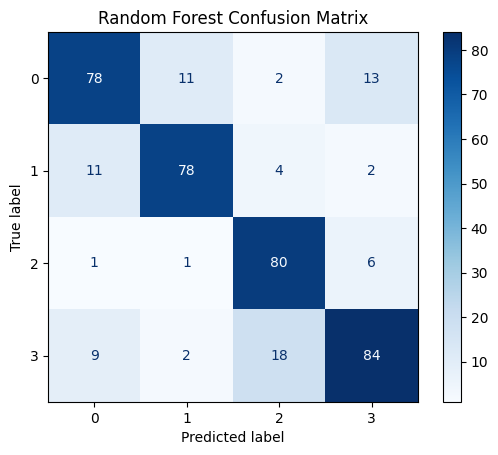

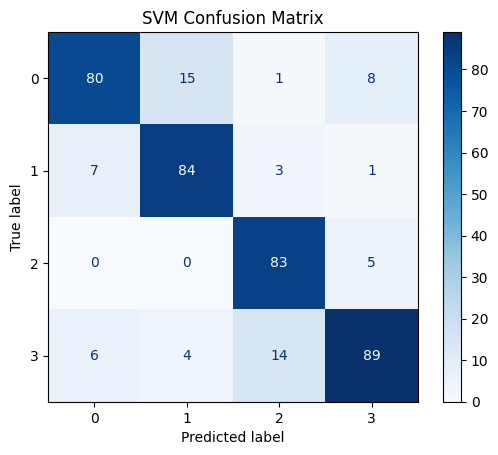

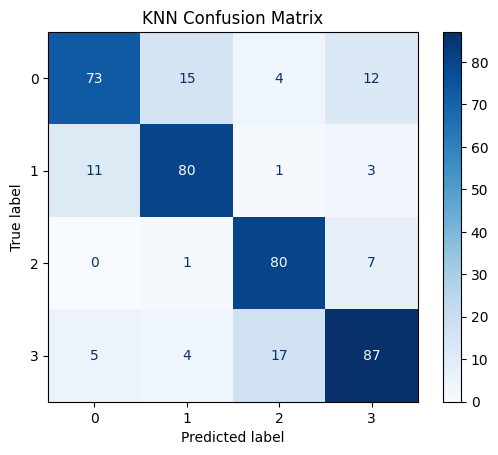

In [152]:
def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap=plt.cm.Blues)
    plt.title(title)
    plt.show()

# Plot confusion matrix for Random Forest
plot_confusion_matrix(y_test, rf.predict(X_test), "Random Forest Confusion Matrix")
# Plot confusion matrix for SVM
plot_confusion_matrix(y_test, svm.predict(X_test), "SVM Confusion Matrix")
# Plot confusion matrix for KNN
plot_confusion_matrix(y_test, knn.predict(X_test), "KNN Confusion Matrix")